# Chapter 7 - Linear Discriminant Analysis (LDA) - Demo

## 1. Generate sample data

[[   27.  9689.]
 [   27. 13076.]
 [   28. 10076.]
 [   25. 11404.]
 [   31.  7748.]]


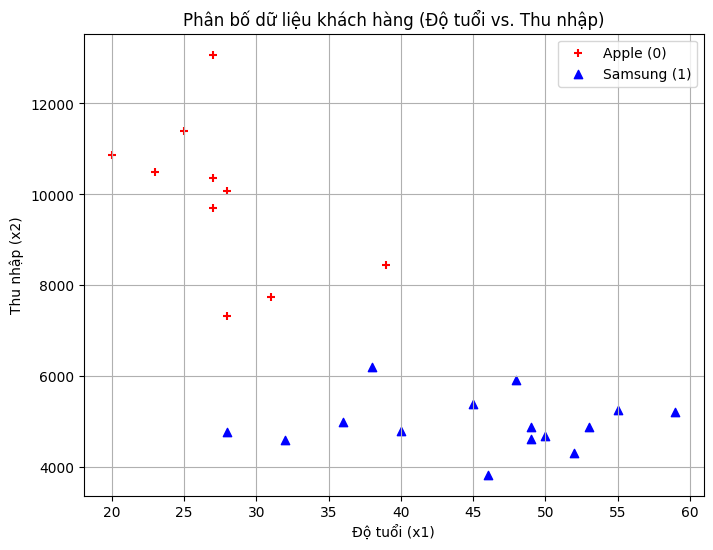

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================
# 1. TẠO DỮ LIỆU GIẢ LẬP CHO HAI NHÓM KHÁCH HÀNG
# ==============================================

# Giả định cho nhóm khách hàng Apple (nhãn lớp = 0):
# - Độ tuổi trung bình trẻ hơn (~30 tuổi)
# - Thu nhập cao hơn (~10.000 USD)
# Sử dụng phân phối chuẩn (Gaussian) để tạo dữ liệu ngẫu nhiên xung quanh giá trị trung bình

# Tạo ra 10 giá trị độ tuổi ngẫu nhiên (dạng cột), phân bố quanh trung bình 30 tuổi, độ lệch chuẩn 5, 
# và được làm tròn để mô phỏng dữ liệu tuổi của nhóm khách hàng Apple
X1_Apple_Age = np.round(30 + np.random.randn(10, 1) * 5)        # Tuổi
X2_Apple_Income = np.round(10000 + np.random.randn(10, 1) * 2000)  # Thu nhập

# Giả định cho nhóm khách hàng Samsung (nhãn lớp = 1):
# - Độ tuổi trung bình lớn hơn (~45 tuổi)
# - Thu nhập thấp hơn (~5.000 USD)
X1_Samsung_Age = np.round(45 + np.random.randn(15, 1) * 10)      # Tuổi
X2_Samsung_Income = np.round(5000 + np.random.randn(15, 1) * 500)  # Thu nhập

# ==============================================
# 2. KẾT HỢP DỮ LIỆU VÀ TẠO MA TRẬN ĐẶC TRƯNG X, NHÃN Y
# ==============================================

# Ghép cột dữ liệu của cả hai nhóm lại với nhau
X1 = np.concatenate((X1_Apple_Age, X1_Samsung_Age))    # Tuổi
X2 = np.concatenate((X2_Apple_Income, X2_Samsung_Income))  # Thu nhập

# Gộp hai đặc trưng (tuổi, thu nhập) thành ma trận X có dạng (số_mẫu, 2)
X = np.column_stack((X1, X2))
print(X[:5])

# Tạo nhãn lớp Y:
# - 10 mẫu đầu là Apple → nhãn 0
# - 15 mẫu tiếp theo là Samsung → nhãn 1
Y = np.concatenate((np.zeros(10), np.ones(15)))

# ==============================================
# 3. TRỰC QUAN HÓA DỮ LIỆU (HÌNH TƯƠNG TỰ HÌNH 7.1)
# ==============================================

plt.figure(figsize=(8, 6))  # Kích thước khung vẽ

# Vẽ các điểm dữ liệu cho nhóm Apple (màu đỏ, dấu '+')
plt.scatter(X[Y == 0, 0], X[Y == 0, 1], 
            marker='+', color='red', label='Apple (0)')

# Vẽ các điểm dữ liệu cho nhóm Samsung (màu xanh, dấu tam giác '^')
plt.scatter(X[Y == 1, 0], X[Y == 1, 1], 
            marker='^', color='blue', label='Samsung (1)')

# Thêm tiêu đề, nhãn trục, chú giải
plt.title('Phân bố dữ liệu khách hàng (Độ tuổi vs. Thu nhập)')
plt.xlabel('Độ tuổi (x1)')
plt.ylabel('Thu nhập (x2)')
plt.legend()
plt.grid(True)  # Hiển thị lưới cho dễ quan sát

# Hiển thị biểu đồ
plt.show()

## 2. Determine LDA Weights

To perform LDA, we calculate discriminant weights (W) based on the data properties:

1. Calculate Class Means ($\mathbf{MeanGroup}$): Compute the mean Age and Income vector for each class ($C_0$ and $C_1$).

2. Calculate Individual Covariance Matrices ($\mathbf{Co}\mathbf{v}_\mathbf{1}$,$\mathbf{Co}\mathbf{v}_\mathbf{2}$): Compute the covariance matrix for Age and Income within each class.

3. Calculate Pooled Covariance Matrix ($\mathbf{PooledCov}$): Combine the individual covariance matrices.

4. Calculate Prior Probabilities ($\mathbf{PriorProb}$): Determine the proportion of records belonging to each class.

5. Calculate Weights ($\mathbf{W}$): Use the Mean Vectors, Pooled Covariance, and Prior Probabilities to solve for the final discriminant weights.


In [ ]:
import numpy as np

# ==========================================
# 1. SINH DỮ LIỆU GIẢ
# ==========================================
# Lớp 1: Apple (tuổi ~30, thu nhập ~10000)
X1_Apple_Age = np.round(30 + np.random.randn(10, 1) * 5)
X2_Apple_Income = np.round(10000 + np.random.randn(10, 1) * 2000)
X_Apple = np.hstack((X1_Apple_Age, X2_Apple_Income))

# Lớp 2: Samsung (tuổi ~45, thu nhập ~5000)
X1_Samsung_Age = np.round(45 + np.random.randn(15, 1) * 10)
X2_Samsung_Income = np.round(5000 + np.random.randn(15, 1) * 500)
X_Samsung = np.hstack((X1_Samsung_Age, X2_Samsung_Income))

# Gộp dữ liệu toàn bộ
X = np.vstack((X_Apple, X_Samsung))
# Gán nhãn lớp (0 = Apple, 1 = Samsung)
Y = np.vstack((np.zeros((10, 1)), np.ones((15, 1)))).ravel()

# ==========================================
# 2. TÍNH VECTOR TRUNG BÌNH CHO TỪNG LỚP
# ==========================================
Mean_Apple = np.mean(X_Apple, axis=0)
Mean_Samsung = np.mean(X_Samsung, axis=0)

print("Vector trung bình (Mean vectors):")
print("Apple:", Mean_Apple)
print("Samsung:", Mean_Samsung)

# ==========================================
# 3. TÍNH MA TRẬN HIỆP PHƯƠNG SAI RIÊNG TỪNG LỚP
# ==========================================
Cov_Apple = np.cov(X_Apple.T)
Cov_Samsung = np.cov(X_Samsung.T)

print("\nMa trận hiệp phương sai (Covariance matrices):")
print("Apple:\n", Cov_Apple)
print("Samsung:\n", Cov_Samsung)

# ==========================================
# 4. TÍNH MA TRẬN HIỆP PHƯƠNG SAI GỘP (Pooled Covariance)
# ==========================================
n1 = X_Apple.shape[0]  # số mẫu lớp 1
n2 = X_Samsung.shape[0]  # số mẫu lớp 2
pooled_cov = ((n1 - 1) * Cov_Apple + (n2 - 1) * Cov_Samsung) / (n1 + n2 - 2)

print("\nMa trận hiệp phương sai gộp (Pooled Covariance):")
print(pooled_cov)

# ==========================================
# 5. TÍNH XÁC SUẤT TIÊN NGHIỆM (Prior Probabilities)
# ==========================================
P1 = n1 / (n1 + n2)
P2 = n2 / (n1 + n2)
print("\nXác suất tiên nghiệm (Prior probabilities):")
print("P(Apple) =", P1)
print("P(Samsung) =", P2)

# ==========================================
# 6. TÍNH TRỌNG SỐ (Weights) CHO HÀM PHÂN BIỆT TUYẾN TÍNH
# ==========================================
# W = Σ⁻¹ * (μ₁ - μ₂)
# Σ⁻¹: Nghịch đảo ma trận hiệp phương sai gộp
# μ₁ - μ₂: Hiệu vector trung bình giữa hai lớp. Vector này chỉ hướng từ tâm lớp μ₁ đến tâm lớp μ₂
inv_pooled = np.linalg.inv(pooled_cov)
W = inv_pooled.dot(Mean_Apple - Mean_Samsung) 


# Hệ số chặn (bias term)
# w0 = -0.5 * μ₁ᵀΣ⁻¹μ₁ + 0.5 * μ₂ᵀΣ⁻¹μ₂ + ln(P₁/P₂)
w0 = (-0.5 * Mean_Apple.dot(inv_pooled).dot(Mean_Apple)
      + 0.5 * Mean_Samsung.dot(inv_pooled).dot(Mean_Samsung)
      + np.log(P1 / P2))

print("\nVector trọng số (Discriminant Weights):")
print("W =", W)
print("w0 =", w0)

## 3. Prediction

The **linear discriminant function** used in **LDA**:

$g(\mathbf{x}) = \mathbf{w}^T \mathbf{x} + w_0$

where:

- $w$: weight vector (computed earlier as Σ⁻¹(μ₁ − μ₂))
- $w_0$: bias term (intercept)
- $x$: input feature vector

**The decision rule of LDA:**

$\text{Predicted class} = \begin{cases} 0 & \text{if } g(x) > 0 \\ 1 & \text{if } g(x) \le 0 \end{cases}$


In [9]:
# ==========================================
# HÀM DỰ ĐOÁN LỚP (PHÂN LOẠI)
# ==========================================
def predict(x, W, w0):
    """Tính giá trị hàm phân biệt tuyến tính g(x) = w^T x + w0"""
    g = W.dot(x) + w0
    return 0 if g > 0 else 1  # 0 = Apple, 1 = Samsung

# Ví dụ dự đoán:
x_test = np.array([40, 8000])  # một người 40 tuổi, thu nhập 8000
label = predict(x_test, W, w0)
print("\nMẫu kiểm thử:", x_test, "→ Dự đoán lớp:", "Apple" if label == 0 else "Samsung")


Mẫu kiểm thử: [  40 8000] → Dự đoán lớp: Samsung
